# Moller scattering of Lorentz-covariant vortex packets

Numerical evaluation of the packet normalization, S-matrix, differential probability, and mean total momentum. Natural units $\hbar=c=1$ are used; energies and momenta are in MeV and impact parameters are in MeV$^{-1}$.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
if (ROOT / "src").exists():
    sys.path.insert(0, str(ROOT / "src"))

import moller_vortex as mv


## 1. Imports and wave-packet definition

The physical and numerical parameters used below are collected in the first code cell.

In [2]:
# Wave-packet parameters
COORDINATE_WIDTH_NM = 1.0
ELL_1, ELL_2 = 1, -1
SIGMA_PARALLEL = 0.05
SIGMA_ENERGY = 0.05
CENTRAL_K_Z = 10.0
IMPACT_NM = 5.0
NONPERIODIC_RULE = "boole"
PERIODIC_RULE = "periodic"  # Endpoint-free trapezoidal rule
NORMALIZATION_K_PERP_POINTS = 65
NORMALIZATION_K_Z_POINTS = 97
NORMALIZATION_K_PERP_WIDTHS = 8.0
NORMALIZATION_K_Z_WIDTHS = 8.0

sigma_perp = mv.spatial_width_nm_to_momentum_mev(COORDINATE_WIDTH_NM)
k_perp_max = (
    NORMALIZATION_K_PERP_WIDTHS
    * np.sqrt(max(abs(ELL_1), abs(ELL_2)) + 1.0)
    * sigma_perp
)
k_z_half_width = (
    NORMALIZATION_K_Z_WIDTHS * max(SIGMA_PARALLEL, SIGMA_ENERGY)
)
normalization_grid1 = mv.NormalizationGrid(
    k_perp=mv.Axis(
        0.0, k_perp_max, NORMALIZATION_K_PERP_POINTS, NONPERIODIC_RULE
    ),
    k_z=mv.Axis(
        CENTRAL_K_Z - k_z_half_width,
        CENTRAL_K_Z + k_z_half_width,
        NORMALIZATION_K_Z_POINTS,
        NONPERIODIC_RULE,
    ),
)
normalization_grid2 = mv.NormalizationGrid(
    k_perp=normalization_grid1.k_perp,
    k_z=mv.Axis(
        -CENTRAL_K_Z - k_z_half_width,
        -CENTRAL_K_Z + k_z_half_width,
        NORMALIZATION_K_Z_POINTS,
        NONPERIODIC_RULE,
    ),
)
packet1 = mv.VortexPacket(
    ell=ELL_1,
    sigma_perp=sigma_perp,
    sigma_parallel=SIGMA_PARALLEL,
    sigma_energy=SIGMA_ENERGY,
    k0_z=CENTRAL_K_Z,
    normalization_grid=normalization_grid1,
)
packet2 = mv.VortexPacket(
    ell=ELL_2,
    sigma_perp=sigma_perp,
    sigma_parallel=SIGMA_PARALLEL,
    sigma_energy=SIGMA_ENERGY,
    k0_z=-CENTRAL_K_Z,
    normalization_grid=normalization_grid2,
)
impact = np.array((0.0, IMPACT_NM / mv.HBARC_MEV_NM))
sigma_total_perp = np.hypot(
    packet1.sigma_perp, packet2.sigma_perp
)

print(f"sigma_perp = {sigma_perp:.8e} MeV")
print(f"impact = {impact} MeV^-1")

sigma_perp = 1.97326980e-04 MeV
impact = [    0.        25338.6535884] MeV^-1


## 2. Normalization

Finite non-periodic integrals use composite Boole quadrature. Consequently, each point count is of the form $4n+1$.

In [3]:
N1 = packet1.norm
N2 = packet2.norm

print(f"N1 = {N1:.12e}")
print(f"N2 = {N2:.12e}")

N1 = 8.047175060298e+05
N2 = 8.047175060298e+05


## 3. S-matrix at one point

In [4]:
# Momentum point
k3_perp_point = np.array((0.020, 0.004))
total_k_perp_point = np.array(
    (0.50 * sigma_total_perp, -0.25 * sigma_total_perp)
)

k4_perp_point = total_k_perp_point - k3_perp_point
momentum_3 = np.array(
    (
        *k3_perp_point,
        np.sqrt(packet1.k0_z**2 - np.sum(k3_perp_point**2)),
    )
)
momentum_4 = np.array(
    (
        *k4_perp_point,
        -np.sqrt(packet2.k0_z**2 - np.sum(k4_perp_point**2)),
    )
)

S = mv.s_matrix(
    momentum_3,
    momentum_4,
    packet1,
    packet2,
    impact=impact,
)

print(f"S = {S}")
print(f"|S|^2 = {np.abs(S)**2:.12e}")

S = (-4106.03303226735-3316.644171727738j)
|S|^2 = 2.785963582393e+07


## 4. Differential-probability grid

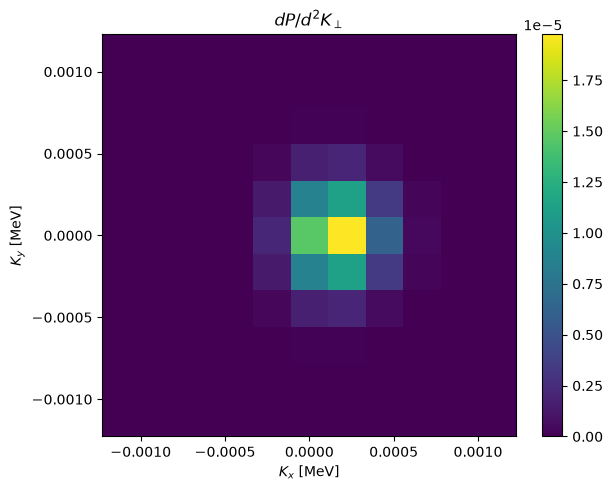

In [5]:
# Probability-integration parameters
K3_PERP_RANGE = (0.010, 0.050)
K3_Z_RANGE = (9.70, 10.30)
K4_Z_RANGE = (-10.30, -9.70)
K3_PERP_POINTS = 13
K3_PHI_POINTS = 16
K3_Z_POINTS = 17
K4_Z_POINTS = 17
TOTAL_K_PERP_POINTS = 9
TOTAL_K_PHI_POINTS = 12
PROBABILITY_BATCH_SIZE = 48
WORKERS = 2
MAP_POINTS = 11
MAP_HALF_WIDTHS = 4.0
TOTAL_K_WIDTHS = 5.0

probability_grid = mv.ProbabilityGrid(
    k3_perp=mv.Axis(
        *K3_PERP_RANGE, K3_PERP_POINTS, NONPERIODIC_RULE
    ),
    k3_phi=mv.Axis(
        0.0, 2.0 * np.pi, K3_PHI_POINTS, PERIODIC_RULE
    ),
    k3_z=mv.Axis(*K3_Z_RANGE, K3_Z_POINTS, NONPERIODIC_RULE),
    k4_z=mv.Axis(*K4_Z_RANGE, K4_Z_POINTS, NONPERIODIC_RULE),
    total_k_perp=mv.Axis(
        0.0,
        TOTAL_K_WIDTHS * sigma_total_perp,
        TOTAL_K_PERP_POINTS,
        NONPERIODIC_RULE,
    ),
    total_k_phi=mv.Axis(
        0.0, 2.0 * np.pi, TOTAL_K_PHI_POINTS, PERIODIC_RULE
    ),
    batch_size=PROBABILITY_BATCH_SIZE,
)

total_k_limit = MAP_HALF_WIDTHS * sigma_total_perp
total_k_x = np.linspace(-total_k_limit, total_k_limit, MAP_POINTS)
total_k_y = np.linspace(-total_k_limit, total_k_limit, MAP_POINTS)
probability_map = mv.differential_probability_grid(
    total_k_x,
    total_k_y,
    packet1,
    packet2,
    probability_grid,
    impact=impact,
    workers=WORKERS,
)

fig, ax = plt.subplots(figsize=(6.4, 5.0))
mesh = ax.pcolormesh(
    total_k_x, total_k_y, probability_map, shading="auto"
)
ax.set(
    xlabel=r"$K_x$ [MeV]",
    ylabel=r"$K_y$ [MeV]",
    title=r"$dP/d^2K_\perp$",
)
fig.colorbar(mesh, ax=ax)
fig.tight_layout()
plt.show()

## 5. Mean total momentum

In [6]:
mean_total_k = mv.mean_total_momentum(
    packet1,
    packet2,
    probability_grid,
    impact=impact,
    workers=WORKERS,
)
print(f"<Kx, Ky, Kz> = {mean_total_k} MeV")

<Kx, Ky, Kz> = [ 1.47079586e-04 -1.19488607e-21 -2.53643622e-14] MeV
